### Import librairies 

In [2]:
library(readxl)
library(ggfortify)
library(edgeR)
library(ggpubr)
library(ggrepel)

Loading required package: ggplot2

Loading required package: limma



In [3]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

### Identify previous clusters in merged space 

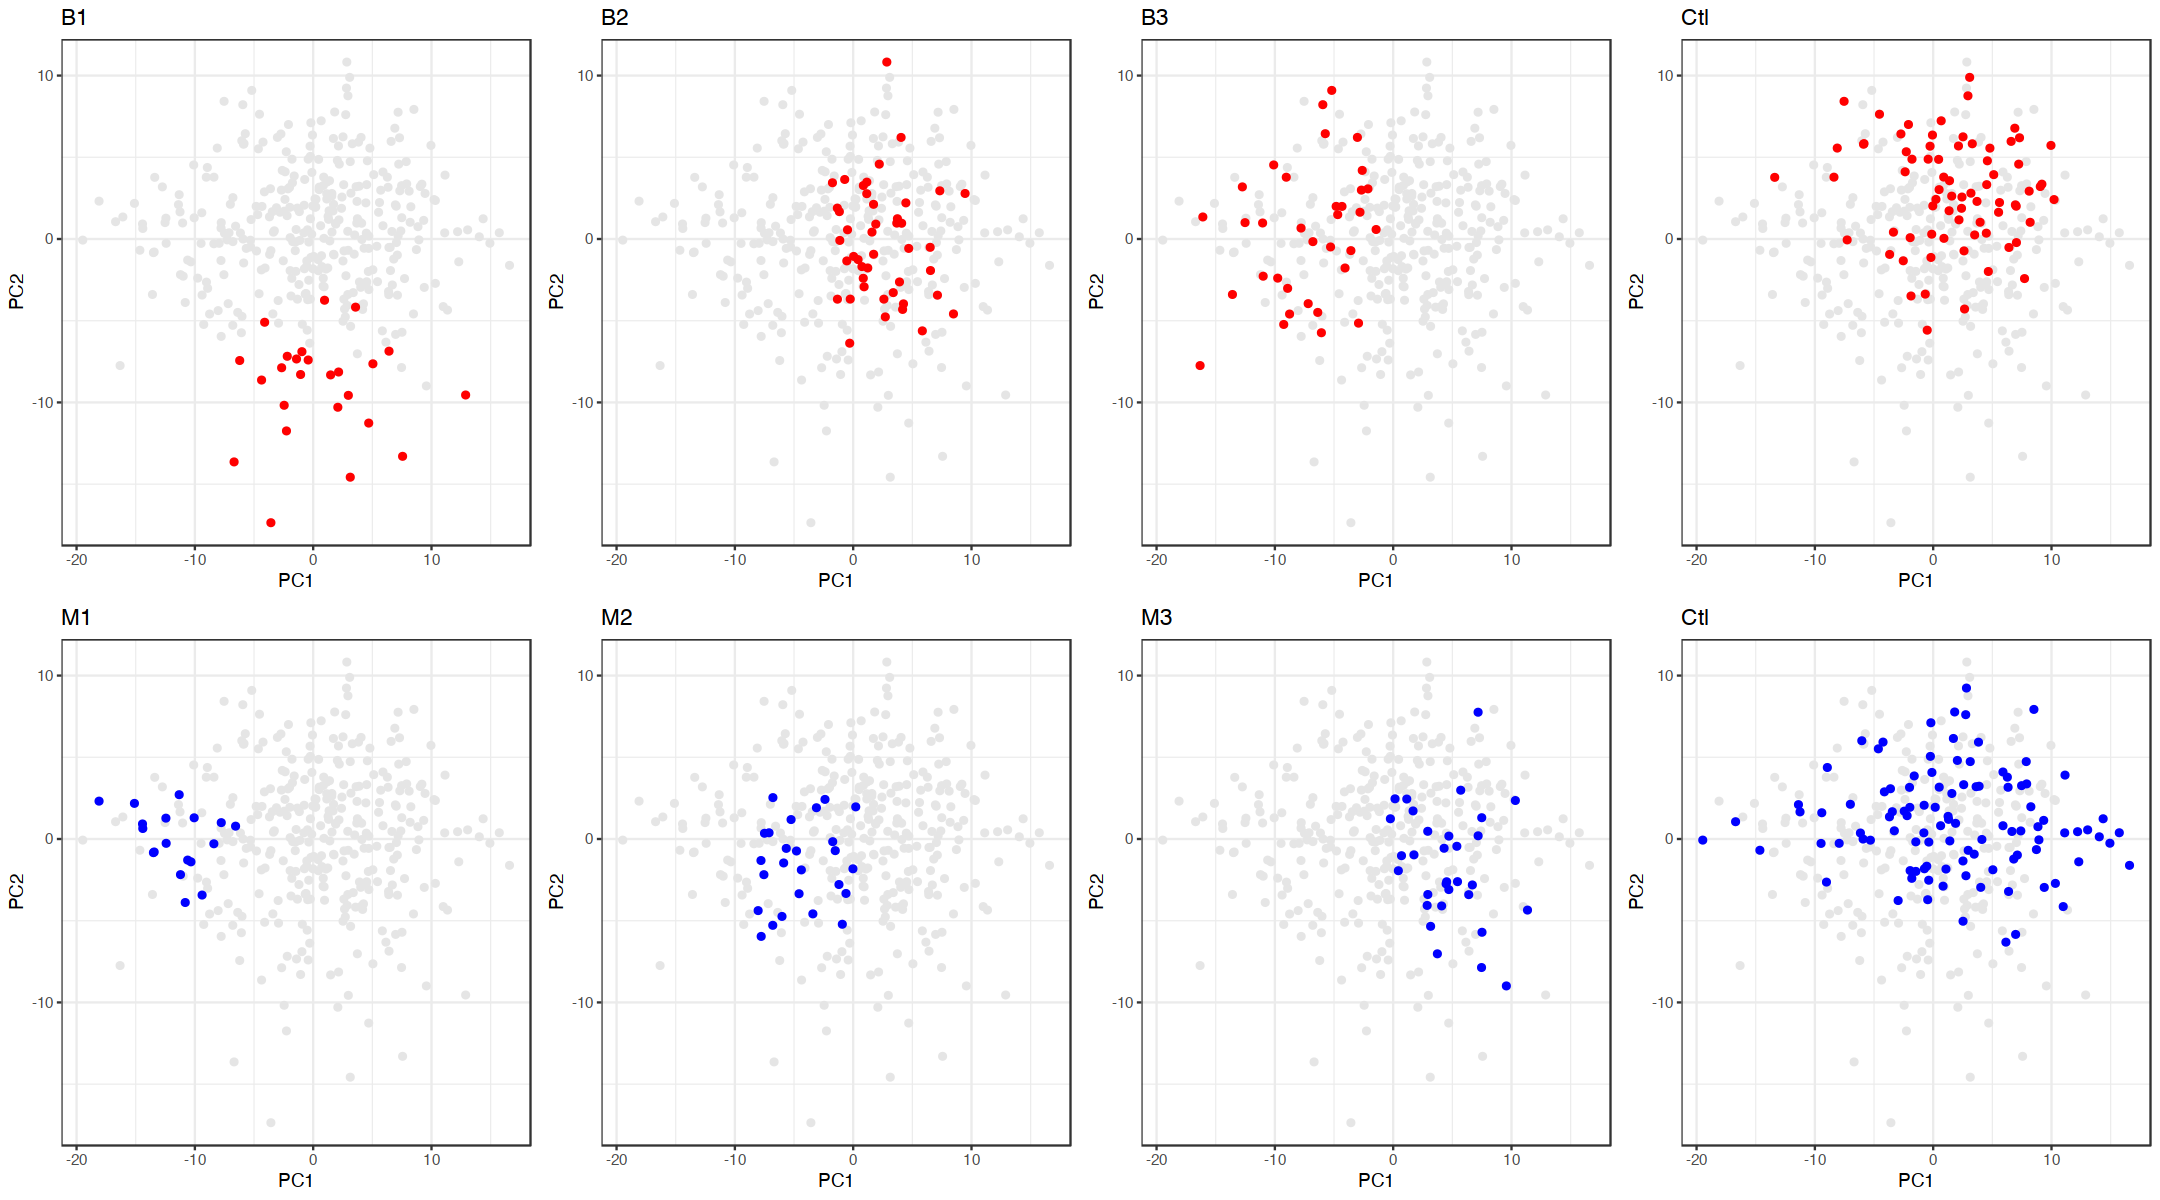

In [4]:
pca = data.frame(prcomp(scaled_df)$x)
meta = meta
meta$PC1 = pca[,1]
meta$PC2 = pca[,2]

for(val in unique(meta$cluster)){
    meta[,gsub('-','.',val)] = meta$cluster == val
}

p1=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,B1=='TRUE'),col='red')+theme_bw()+ggtitle('B1')
p2=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,B2=='TRUE'),col='red')+theme_bw()+ggtitle('B2')
p3=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,B3=='TRUE'),col='red')+theme_bw()+ggtitle('B3')
p4=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,B.CTL=='TRUE'),col='red')+theme_bw()+ggtitle('Ctl')

p5=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,M1=='TRUE'),col='blue')+theme_bw()+ggtitle('M1')
p6=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,M2=='TRUE'),col='blue')+theme_bw()+ggtitle('M2')
p7=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,M3=='TRUE'),col='blue')+theme_bw()+ggtitle('M3')
p8=ggplot(meta,aes(PC1,PC2))+geom_point(col='grey90')+geom_point(data=subset(meta,M.CTL=='TRUE'),col='blue')+theme_bw()+ggtitle('Ctl')

options(repr.plot.width = 18, repr.plot.height = 10)

cowplot::plot_grid(p1,p2,p3,p4,p5,p6,p7,p8,ncol=4)

### Compare Control vs HFpEF differences between the 2 datasets in the merged space 

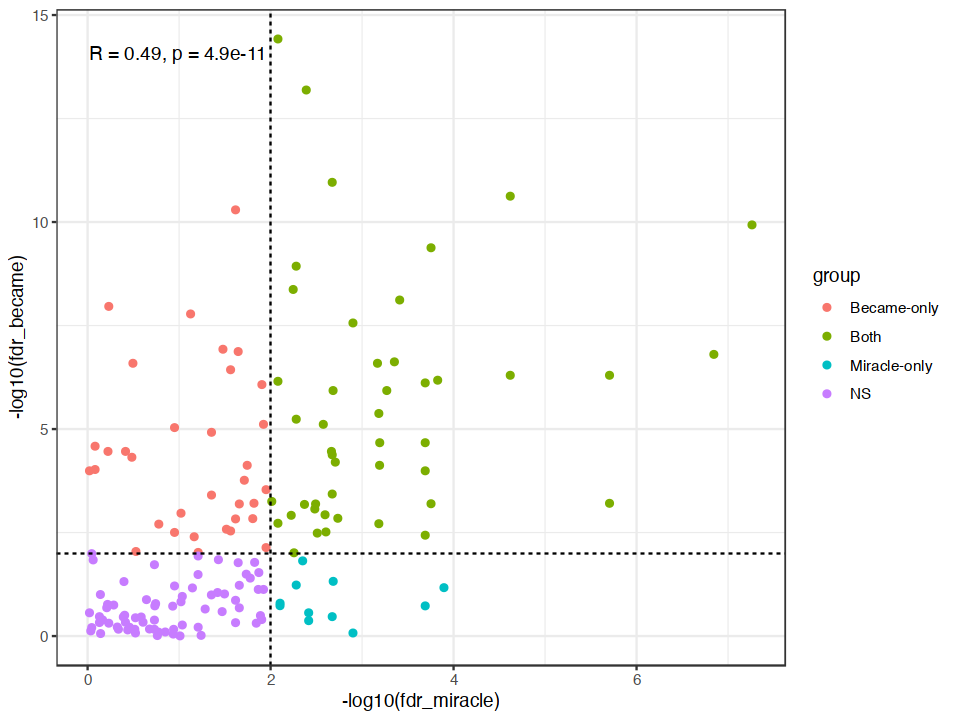

In [5]:
m2 = data.frame(scaled_df)

m2$cluster = meta[rownames(m2),'cluster']
m2$group = meta[rownames(m2),'group']
res = data.frame()
for(i in 1:(ncol(m2)-2)){
    m2_b = subset(m2,grepl('^B',cluster))
    m2_m = subset(m2,grepl('^M',cluster))
    test_m = t.test(m2_m[,i]~group,data=m2_m)
    test_b = t.test(m2_b[,i]~group,data=m2_b)
    pval_m = test_m$p.value
    pval_b = test_b$p.value
    res = rbind(res,c(pval_m,pval_b,colnames(m2)[i]))
}
res[,1] = as.numeric(res[,1])
res[,2] = as.numeric(res[,2])
colnames(res) = c('pval_miracle','pval_became','lipid')
res$fdr_miracle = p.adjust(res$pval_miracle, method = "fdr")
res$fdr_became = p.adjust(res$pval_became, method = "fdr")


res$group = 'NS'
res[which(res$fdr_miracle<0.01&res$fdr_became<0.01),'group'] = 'Both'
res[which(res$fdr_miracle<0.01&res$fdr_became>=0.01),'group'] = 'Miracle-only'
res[which(res$fdr_miracle>=0.01&res$fdr_became<0.01),'group'] = 'Became-only'

options(repr.plot.width = 8, repr.plot.height = 6)

ggplot(res,aes(-log10(fdr_miracle),-log10(fdr_became)))+
    geom_point(aes(col=group))+
    stat_cor()+
    theme_bw()+
    geom_hline(yintercept=-log10(0.01),linetype='dashed')+
    geom_vline(xintercept=-log10(0.01),linetype='dashed')

### Identify correlations between clusters in terms of average lipid profiles

In [6]:
options(repr.plot.width = 8, repr.plot.height = 6)

ag = aggregate(m2[,-c(ncol(m2)-1,ncol(m2))],by=list(m2$cluster),mean)
rownames(ag) = ag[,1]
cor_mat = cor(t(ag[,-c(1,ncol(ag))]))


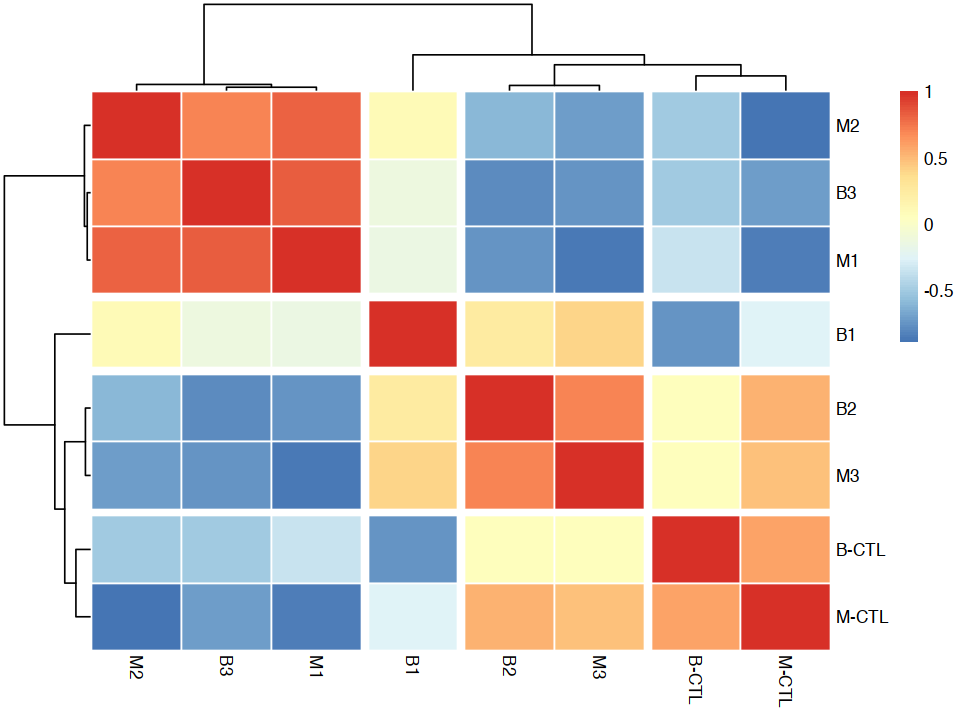

In [7]:
pheatmap::pheatmap(cor_mat,border_col='white',clustering_method='ward.D2',cutree_row=4,cutree_col=4)

### Identify statistical differences between clusters with ANOVA

In [8]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
rownames(became_meta) = paste0('X',became_meta[,1])

became_num = became[,-c(1:7)]
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
became_num = data.frame(log(became_num))

became_scaled = data.frame(t(scaled_df[rownames(became_meta),]))

In [9]:
res=data.frame()
for(i in 1:nrow(became_num)){
    test_og = aov(as.numeric(became_num[i,])~factor(became_meta[colnames(became_num),'cluster.Became']))
    test_scaled = aov(as.numeric(became_scaled[i,])~factor(became_meta[colnames(became_scaled),'cluster.Became']))

    p_value_og <- summary(test_og)[[1]][["Pr(>F)"]][1]
    p_value_scaled <- summary(test_scaled)[[1]][["Pr(>F)"]][1]
    res = rbind(res,c(p_value_og,p_value_scaled,rownames(became_num)[i]))

}

In [10]:
res$compound_name = became[rownames(res),'Lipid.ID']

In [11]:
colnames(res)[1:3] = c('pval_og','pval_scaled','compound_id')
res$compound_name = factor(res$compound_name,levels=unique(res[order(-as.numeric(res$pval_og)),'compound_name']))
res$pval_og = as.numeric(res$pval_og)
res$pval_scaled = as.numeric(res$pval_scaled)

res = res[order(res$pval_og),]

res$unique_values <- with(res, ave(as.character(compound_name), as.character(compound_name), FUN = function(x) {
  if (sum(duplicated(x)) > 0) {
    seq_along(x)
  } else {
    rep(1, length(x))
  }
}))
res$unique_name = paste(res$compound_name,res$unique_values,sep='.')
res$unique_name = factor(res$unique_name,levels=unique(res[order(-as.numeric(res$pval_og)),'unique_name']))

In [12]:
became_scaled = data.frame(t(became_scaled))
became_scaled = subset(became_scaled,!is.na(X1))
became_scaled$cluster = became_meta[rownames(became_scaled),'cluster.Became']

In [13]:

became_scaled_bplot = became_scaled[,c(paste0('X',rownames(head(res,4))),'cluster')]
m=reshape2::melt(became_scaled_bplot)
m$lipid_name = became[gsub('X','',as.character(m$variable)),'Lipid.ID']
bplot = ggplot(m,aes(cluster,value))+
    geom_boxplot(aes(fill=cluster),outlier.shape=NA)+
    facet_wrap(~lipid_name,scales='free')+
    theme_bw()+
    geom_point(position=position_jitter(width=.1),size=.2)

Using cluster as id variables



In [14]:
splot = ggplot(subset(res,pval_og<1e-13),aes(-log10(as.numeric(pval_og)),unique_name))+
    geom_col(width=.8)+
    theme_bw()

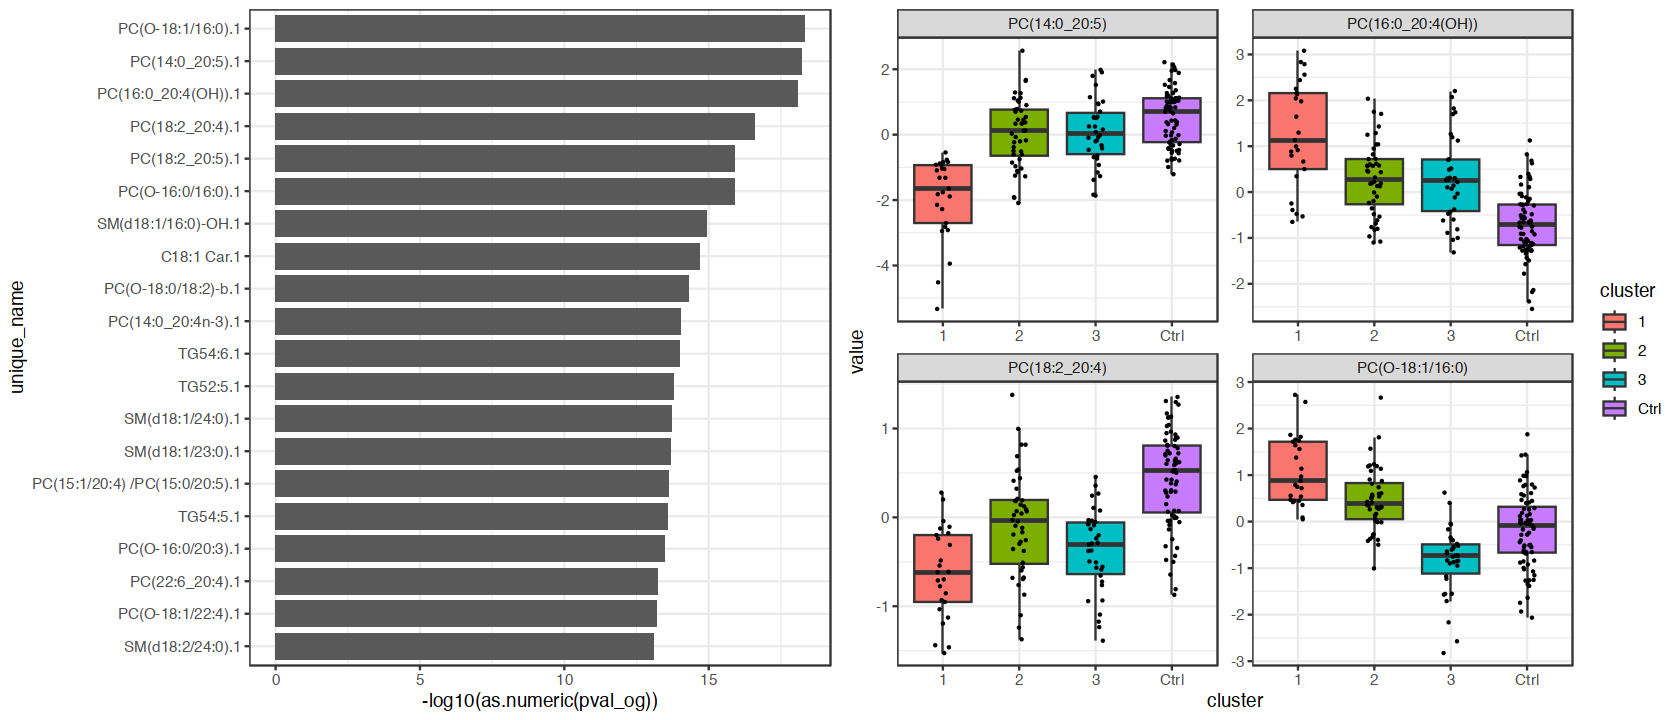

In [15]:
options(repr.plot.width = 14, repr.plot.height = 6)
cowplot::plot_grid(splot,bplot)

In [22]:
res$padj = p.adjust(res$pval_og, method = "BH")

In [44]:
df = data.frame(cbind(scaled_df[,paste0('X',rownames(subset(res,padj<0.000001)))],meta[rownames(scaled_df),'cluster']))
colnames(df)[ncol(df)]='cluster'
df = df[grepl('^B',df$cluster),]
head(df)

,X51,X62,X38,X77,X78,X39,X110,X3,X49,X61,⋯,X84,X14,X5,X23,X86,X130,X87,X7,X27,cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
X10299,-0.8983013,0.5200446,-0.4269499,0.2676591,-0.2393362,-0.3268149,-0.9361327,-1.1343091,-1.6516606,1.1099979,⋯,0.07896501,-1.23717347,-1.3263165,-0.8940163,-0.1642985,-0.4926789,-0.6920288,1.7207084,-0.7995261,B3
X10301,1.5673011,0.1198835,0.9469403,0.2082293,-0.5189024,1.7192045,0.5412364,0.9939351,1.0723487,0.4062843,⋯,0.77145769,-0.09225713,-1.1355529,0.2971176,1.5006965,-1.1475952,1.6412117,0.3383759,0.3138234,B2
X10302,0.3437970,1.0078115,-1.1003267,0.1829572,-1.0142946,0.1875692,-0.3986834,-0.1411444,0.3536093,2.0265370,⋯,1.17749818,-0.84206116,2.6464690,-1.7753880,0.8429794,-1.0375358,0.6434468,1.8148435,-0.6725491,B2
X10303,0.3174055,-0.1732094,0.8216796,-0.5974437,-0.8689131,0.7070580,1.0083737,1.6513681,0.4386753,-0.4130230,⋯,1.38322404,-0.44642476,0.5329599,-0.9223864,0.5563971,-0.1410046,0.4612682,0.1280366,-0.5620115,B2
X10304,0.7905969,-0.9312457,2.1320964,-1.4391665,-2.1042307,1.2287188,2.4703222,1.0580195,0.2066600,-0.5284894,⋯,-1.74557645,-0.54161925,0.5653729,-0.8150936,-1.8980048,-0.4839821,-2.1441246,-0.1204555,-0.9591994,B1
X10305,0.7477933,-3.9430340,0.3453470,-0.2395397,-2.3909283,1.7362339,0.3460064,0.2041189,-0.2588288,-2.1812752,⋯,-1.10661101,-1.00549777,0.0722589,-1.7662634,-0.2522070,0.9601209,-0.5820949,-0.8096123,-1.2603739,B1


In [45]:
ag = aggregate(df,by=list(df$cluster),mean)

Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”
Warning message in mean.default(X[[i]], ...):
“argument is not numeric or logical: returning NA”


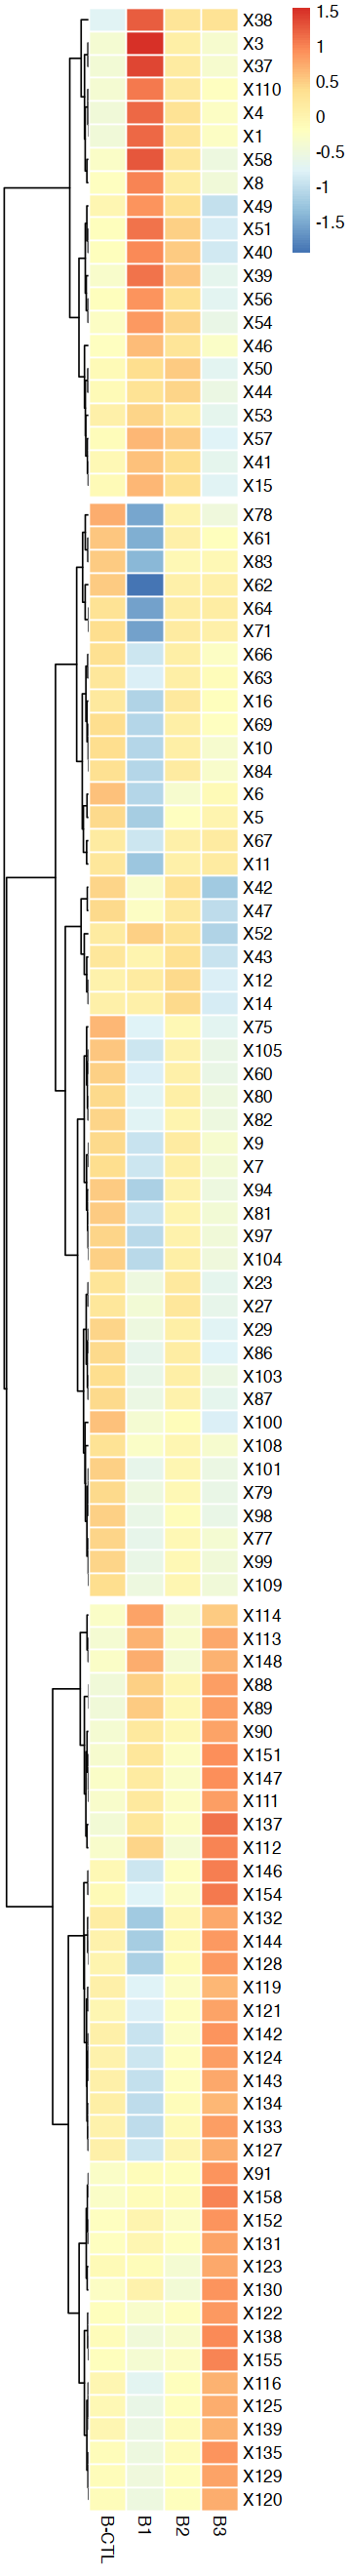

In [60]:
options(repr.plot.width = 3, repr.plot.height = 22)

rownames(ag) = ag[,1]
pheatmap::pheatmap(t(ag[,-c(1,ncol(ag))]),
                   clustering_method='ward.D2',
                   border_col='white',cutree_rows=3,cluster_cols=F)